In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('ibm_telco.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

pd.set_option('display.max_columns', None)

print(f"Satır sayısı: {df.shape[0]}, Kolon sayısı: {df.shape[1]}")
print(df.dtypes)
print(df.describe())


Satır sayısı: 7043, Kolon sayısı: 22
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
Churn_Binary          int64
dtype: object
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges  Churn_Binary
count    7043.000000  7043.000000     7043.000000   7032.000000   7043.000000
mean        0.162147    32.371149       64.761692   2283.300441      0.265370
std         0.368612    24.559481       30.090047   2266.771362      0.441561
min         0.000000 

         Kolon  Ortalama  Alt Sınır  Üst Sınır  Outlier Sayısı  Outlier %
        tenure     32.37     -60.00     124.00               0        0.0
MonthlyCharges     64.76     -46.02     171.38               0        0.0
  TotalCharges   2283.30   -4688.48    8884.67               0        0.0


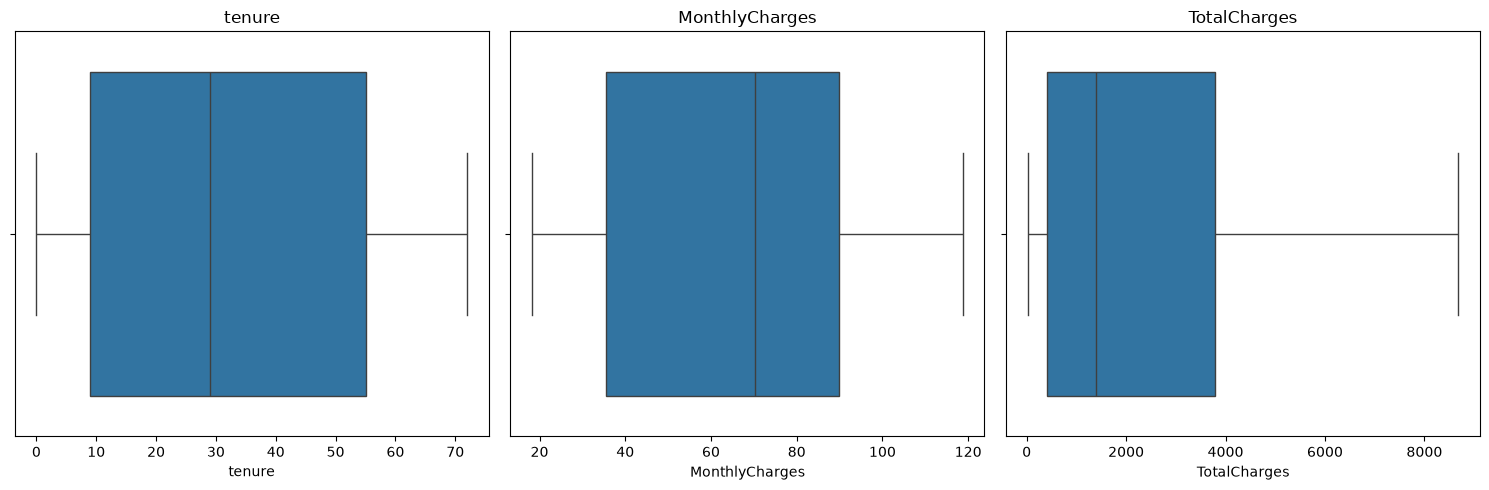

In [12]:


numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

outlier_summary = []
for c in numeric_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    alt, ust = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[c] < alt) | (df[c] > ust)).sum()
    outlier_summary.append({
        'Kolon': c, 'Ortalama': round(df[c].mean(), 2),
        'Alt Sınır': round(alt, 2), 'Üst Sınır': round(ust, 2),
        'Outlier Sayısı': n_out, 'Outlier %': round(n_out/len(df)*100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, c in enumerate(numeric_cols):
    sns.boxplot(x=df[c], ax=axes[i])
    axes[i].set_title(c)
plt.tight_layout()
plt.show()

Sayısal:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Yüzde (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Genel churn oranı: 26.54%


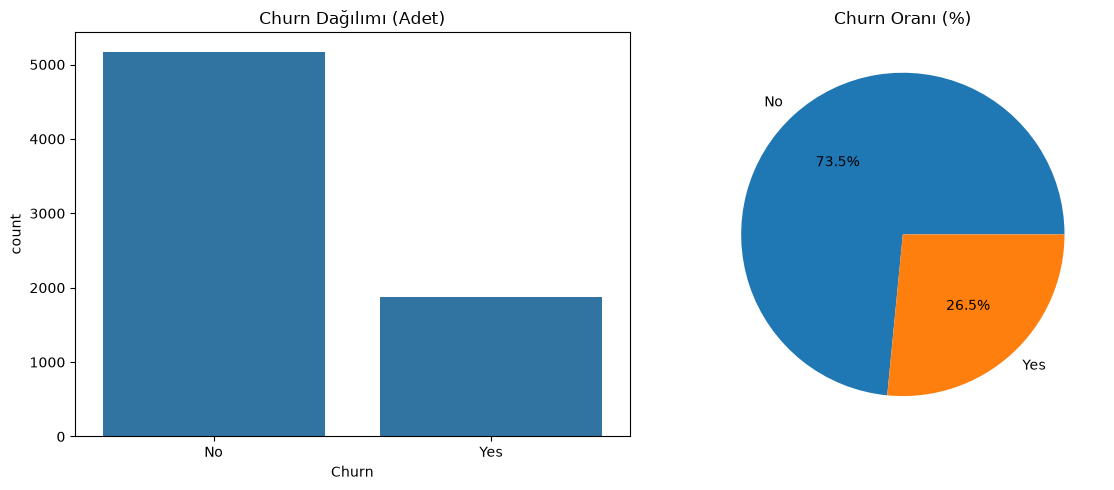

In [13]:
print("Sayısal:")
print(df['Churn'].value_counts())
print("\nYüzde (%):")
print(df['Churn'].value_counts(normalize=True) * 100)
print(f"\nGenel churn oranı: {df['Churn_Binary'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title('Churn Dağılımı (Adet)')
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Churn Oranı (%)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


Kategorik değişkenlere göre churn oranı (%):

--- Contract ---
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn_Binary, dtype: float64

--- InternetService ---
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn_Binary, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn_Binary, dtype: float64

--- PaperlessBilling ---
PaperlessBilling
Yes    33.57
No     16.33
Name: Churn_Binary, dtype: float64


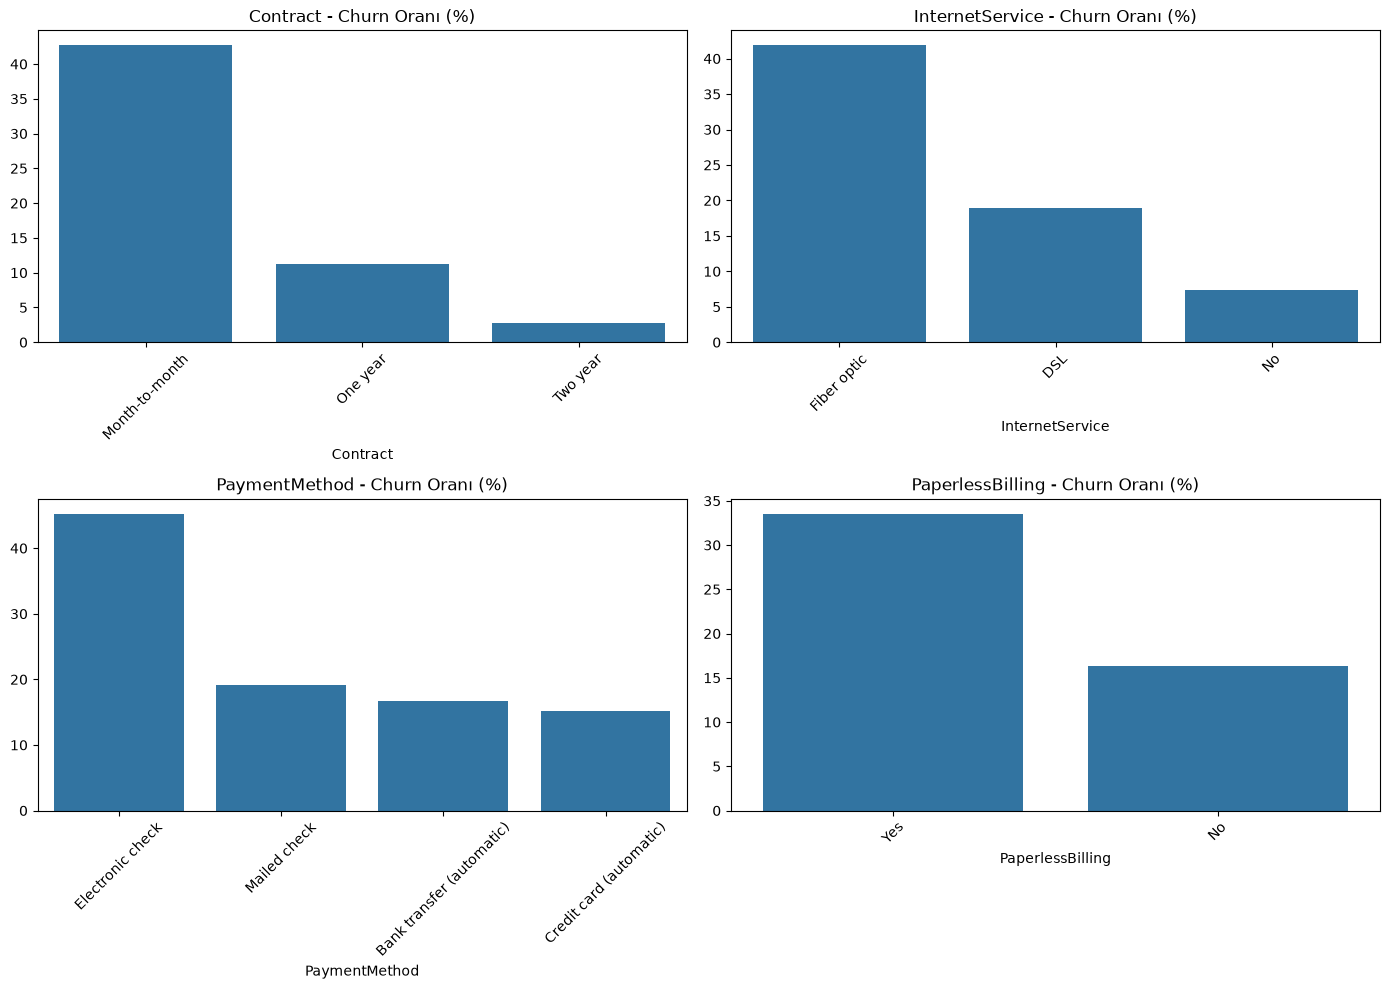

In [14]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
print("\nKategorik değişkenlere göre churn oranı (%):")
for c in cat_cols:
    rate = df.groupby(c)['Churn_Binary'].mean().sort_values(ascending=False) * 100
    print(f"\n--- {c} ---")
    print(rate.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, c in enumerate(cat_cols):
    churn_rate = df.groupby(c)['Churn_Binary'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[i])
    axes[i].set_title(f'{c} - Churn Oranı (%)')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

                tenure  MonthlyCharges  TotalCharges  Churn_Binary  \
tenure            1.00            0.25          0.83         -0.35   
MonthlyCharges    0.25            1.00          0.65          0.19   
TotalCharges      0.83            0.65          1.00         -0.20   
Churn_Binary     -0.35            0.19         -0.20          1.00   
SeniorCitizen     0.02            0.22          0.10          0.15   

                SeniorCitizen  
tenure                   0.02  
MonthlyCharges           0.22  
TotalCharges             0.10  
Churn_Binary             0.15  
SeniorCitizen            1.00  

Churn ile korelasyon (büyükten küçüğe):
Churn_Binary      1.000
MonthlyCharges    0.193
SeniorCitizen     0.151
TotalCharges     -0.199
tenure           -0.352
Name: Churn_Binary, dtype: float64


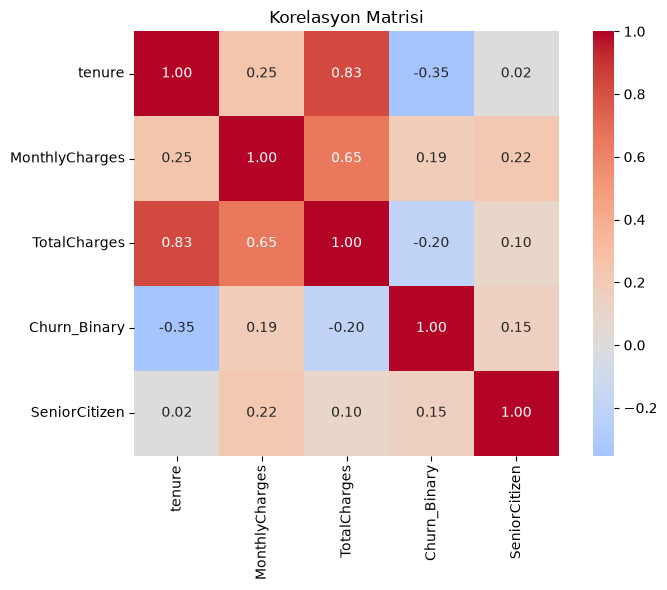

In [15]:
corr_cols = numeric_cols + ['Churn_Binary', 'SeniorCitizen']
corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(2))
print("\nChurn ile korelasyon (büyükten küçüğe):")
print(corr_matrix['Churn_Binary'].sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()



--- tenure (Churn'e göre ortalama) ---
        mean  median    std
Churn                      
No     37.57    38.0  24.11
Yes    17.98    10.0  19.53

--- MonthlyCharges (Churn'e göre ortalama) ---
        mean  median    std
Churn                      
No     61.27   64.43  31.09
Yes    74.44   79.65  24.67

--- TotalCharges (Churn'e göre ortalama) ---
          mean   median      std
Churn                           
No     2555.34  1683.60  2329.46
Yes    1531.80   703.55  1890.82


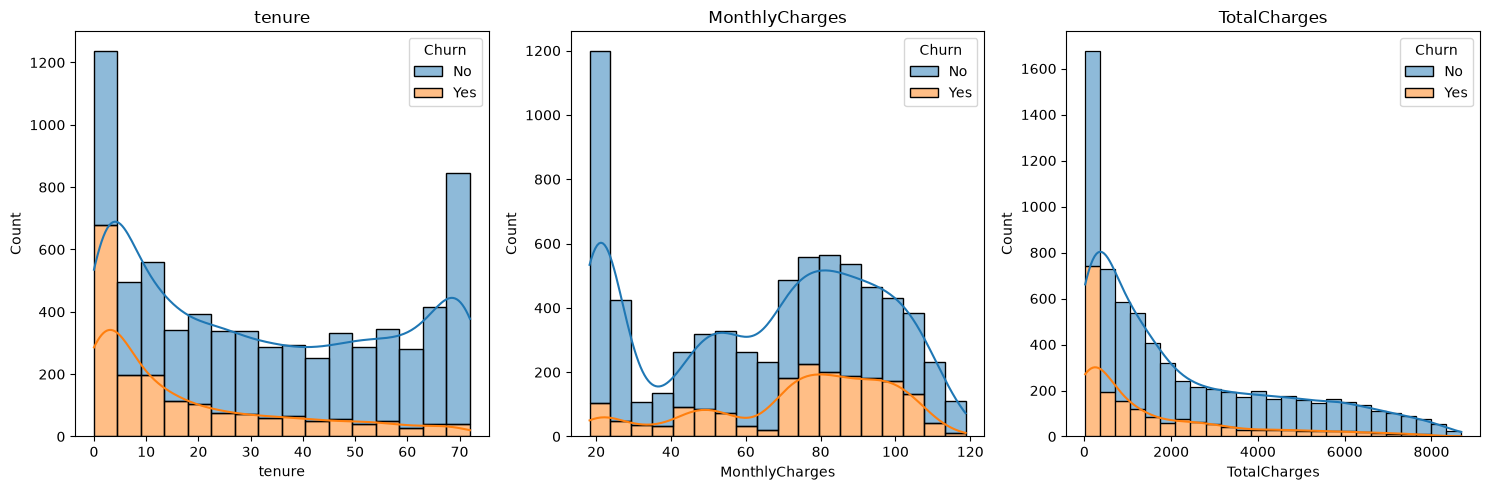

In [16]:

for c in numeric_cols:
    print(f"\n--- {c} (Churn'e göre ortalama) ---")
    print(df.groupby('Churn')[c].agg(['mean', 'median', 'std']).round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, c in enumerate(numeric_cols):
    sns.histplot(data=df, x=c, hue='Churn', kde=True, ax=axes[i], multiple='stack')
    axes[i].set_title(c)
plt.tight_layout()
plt.show()


In [19]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for c in numeric_cols:
    neg_count = (df[c] < 0).sum()
    print(f"{c}: {neg_count} ")
    if neg_count > 0:
        print(df[df[c] < 0])

tenure: 0 
MonthlyCharges: 0 
TotalCharges: 0 
